### Read SNOWPACK Output at All Sites and Perform Statistics on it 

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now

ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

/tmp/ipykernel_490509/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_490509/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_490509/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_490509/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_490509/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.

### Open Observations

In [5]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [6]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

# Temporary Fix the Tram Snow Depth

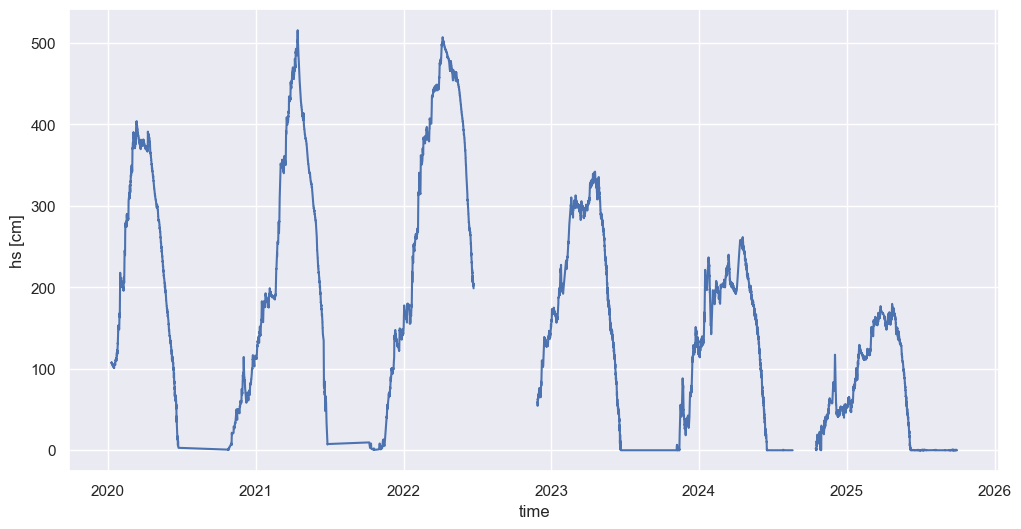

In [7]:
# check the tram snow depth in ds_obs_tram['hs'] and if the rate of change is too high, then remove a few values in a row after that 
# # small cleaning of the hs data which looks awful (remove if I end up doing this somewhere else)
ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2024-05-01T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2024-05-20T23:59")))) # the drop in 2024
ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2025-02-20T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2025-03-04T23:59")))) # the spike in 2025
# ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2025-02-20T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2025-03-04T23:59")))) # more...

# for the tram, shift any values which are below 30 cm in July, August, Sept to 0 

ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2020-01-10", "2025-09-30"))
ds_obs_ppsa['hs'] = ds_obs_ppsa['hs'].where(~((ds_obs_ppsa['time'] >= np.datetime64("2024-08-20T00:00")) & (ds_obs_ppsa['time'] <= np.datetime64("2024-10-15T23:59")))) # the spike in 2025
ds_obs_ppsa['hs'].plot()

## Cut to just three years each

In [8]:
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2022-09-30"))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-10-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-10-01", "2025-09-30"))

# Statistics

#### List of everything: 

`RMSE`

> Overall snow depth performance

`Bias`
> Mean over/underprediction

`MAE`
> Robust average absolute error

`Peak Snow Depth Error`
> Magnitude error of seasonal max

`Snow Onset Error`
> Early/late snowpack establishment

`Peak Date Error`
> Timing of seasonal maximum

`Snow Disappearance Error`	
> Melt-out timing performance

`Melt Duration Error`
> Melt season representation

#### Most common in snow hydro papers, 
RMSE

Bias

Peak SWE/HS error

Peak timing error

Melt-out timing error


In [9]:
import numpy as np
import pandas as pd
import xarray as xr

# ============================================================
# Snow depth threshold for snow presence
# ============================================================

snow_threshold_cm = 5.0

# ============================================================
# Helper functions
# ============================================================

def calculate_rmse(model, obs):

    return np.sqrt(
        np.nanmean((model - obs) ** 2)
    )


def calculate_bias(model, obs):

    return np.nanmean(model - obs)


def calculate_mae(model, obs):

    return np.nanmean(
        np.abs(model - obs)
    )


def calculate_peak_error(model, obs):

    model_peak = np.nanmax(model)
    obs_peak = np.nanmax(obs)

    return model_peak - obs_peak


def calculate_peak_date_error(model_da, obs_da):

    model_peak_date = pd.Timestamp(
        model_da.time.values[
            np.nanargmax(model_da.values)
        ]
    )

    obs_peak_date = pd.Timestamp(
        obs_da.time.values[
            np.nanargmax(obs_da.values)
        ]
    )

    return (
        model_peak_date - obs_peak_date
    ).days


# ============================================================
# Snow timing metrics
# ============================================================

def get_snow_onset_date(da, threshold=5):

    snow = da >= threshold

    if snow.any():

        return pd.Timestamp(
            da.time.where(snow, drop=True).values[0]
        )

    return pd.NaT


def get_snow_disappearance_date(da, threshold=5):

    snow = da >= threshold

    if snow.any():

        return pd.Timestamp(
            da.time.where(snow, drop=True).values[-1]
        )

    return pd.NaT


def get_peak_snow_date(da):

    return pd.Timestamp(
        da.time.values[
            np.nanargmax(da.values)
        ]
    )


def get_melt_duration_days(da, threshold=5):

    peak_date = get_peak_snow_date(da)

    disappearance_date = get_snow_disappearance_date(
        da,
        threshold=threshold
    )

    if pd.isnull(peak_date) or pd.isnull(disappearance_date):

        return np.nan

    return (disappearance_date - peak_date).days


# ============================================================
# Compute all statistics
# ============================================================

def compute_snowpack_statistics(
    model_da,
    obs_da,
    model_name,
    site_name,
    threshold=5
):

    # --------------------------------------------------------
    # Convert to DataFrame and align
    # --------------------------------------------------------

    model_df = model_da.to_dataframe(name='model')
    obs_df = obs_da.to_dataframe(name='obs')

    df = pd.concat(
        [model_df, obs_df],
        axis=1
    ).dropna()

    # --------------------------------------------------------
    # Convert back to arrays
    # --------------------------------------------------------

    model = df['model'].values
    obs = df['obs'].values

    # --------------------------------------------------------
    # Create aligned DataArrays
    # --------------------------------------------------------

    model_aligned = xr.DataArray(
        model,
        coords={'time': df.index},
        dims=['time']
    )

    obs_aligned = xr.DataArray(
        obs,
        coords={'time': df.index},
        dims=['time']
    )

    # --------------------------------------------------------
    # Magnitude metrics
    # --------------------------------------------------------

    rmse = calculate_rmse(model, obs)

    bias = calculate_bias(model, obs)

    mae = calculate_mae(model, obs)

    peak_error = calculate_peak_error(
        model,
        obs
    )

    peak_date_error = calculate_peak_date_error(
        model_aligned,
        obs_aligned
    )

    # --------------------------------------------------------
    # Timing metrics
    # --------------------------------------------------------

    model_onset = get_snow_onset_date(
        model_aligned,
        threshold
    )

    obs_onset = get_snow_onset_date(
        obs_aligned,
        threshold
    )

    onset_error_days = (
        model_onset - obs_onset
    ).days

    model_disappearance = get_snow_disappearance_date(
        model_aligned,
        threshold
    )

    obs_disappearance = get_snow_disappearance_date(
        obs_aligned,
        threshold
    )

    disappearance_error_days = (
        model_disappearance - obs_disappearance
    ).days

    model_peak_date = get_peak_snow_date(
        model_aligned
    )

    obs_peak_date = get_peak_snow_date(
        obs_aligned
    )

    peak_date_error_days = (
        model_peak_date - obs_peak_date
    ).days

    model_melt_duration = get_melt_duration_days(
        model_aligned,
        threshold
    )

    obs_melt_duration = get_melt_duration_days(
        obs_aligned,
        threshold
    )

    melt_duration_error_days = (
        model_melt_duration - obs_melt_duration
    )

    # --------------------------------------------------------
    # Build results dictionary
    # --------------------------------------------------------

    results = {
        'Site': site_name,
        'Model': model_name,

        # Magnitude metrics
        'RMSE (cm)': np.round(rmse, 2),
        'Bias (cm)': np.round(bias, 2),
        'MAE (cm)': np.round(mae, 2),
        'Peak Snow Depth Error (cm)': np.round(peak_error, 2),

        # Timing metrics
        'Snow Onset Error (days)': onset_error_days,
        'Peak Date Error (days)': peak_date_error_days,
        'Snow Disappearance Error (days)': disappearance_error_days,
        'Melt Duration Error (days)': melt_duration_error_days,

        # Additional diagnostic info
        'Observed Peak Snow Depth (cm)': np.round(
            np.nanmax(obs),
            2
        ),

        'Modeled Peak Snow Depth (cm)': np.round(
            np.nanmax(model),
            2
        )
    }

    return results


# ============================================================
# Build list of site/model comparisons
# ============================================================

comparisons = [

    # --------------------------------------------------------
    # PPSA
    # --------------------------------------------------------

    {
        'site': 'PPSA',
        'model_name': 'HRRR-AK Forcing',
        'model': ds_snowpack_hrrrak_ppsa.HS_mod,
        'obs': ds_obs_ppsa['hs']
    },

    {
        'site': 'PPSA',
        'model_name': 'Met Station (Mixed) Forcing',
        'model': ds_snowpack_met_hrrrak_ppsa.HS_mod,
        'obs': ds_obs_ppsa['hs']
    },

    # --------------------------------------------------------
    # TRAM
    # --------------------------------------------------------

    {
        'site': 'TRAM',
        'model_name': 'HRRR-AK Forcing',
        'model': ds_snowpack_hrrrak_tram.HS_mod,
        'obs': ds_obs_tram['hs']
    },

    {
        'site': 'TRAM',
        'model_name': 'Met Station (Mixed) Forcing',
        'model': ds_snowpack_met_hrrrak_tram.HS_mod,
        'obs': ds_obs_tram['hs']
    },

    # --------------------------------------------------------
    # HEEN
    # --------------------------------------------------------

    {
        'site': 'HEEN',
        'model_name': 'HRRR-AK Forcing',
        'model': ds_snowpack_hrrrak_heen.HS_mod,
        'obs': ds_obs_heen['hs']
    },

    {
        'site': 'HEEN',
        'model_name': 'Met Station (Mixed) Forcing',
        'model': ds_snowpack_met_hrrrak_heen.HS_mod,
        'obs': ds_obs_heen['hs']
    }
]

# ============================================================
# Calculate all statistics
# ============================================================

results = []

for comparison in comparisons:

    stats = compute_snowpack_statistics(
        model_da=comparison['model'],
        obs_da=comparison['obs'],
        model_name=comparison['model_name'],
        site_name=comparison['site'],
        threshold=snow_threshold_cm
    )

    results.append(stats)

# ============================================================
# Create results table
# ============================================================

df_results = pd.DataFrame(results)

# ============================================================
# Display results
# ============================================================

print('\n')
print('========================================================')
print('SNOWPACK MODEL PERFORMANCE SUMMARY')
print('========================================================')
print('\n')

print(
    df_results.to_string(index=False)
)

# ============================================================
# Optional:
# Save table to CSV
# ============================================================

# df_results.to_csv(
#     'snowpack_model_performance_metrics.csv',
#     index=False
# )



SNOWPACK MODEL PERFORMANCE SUMMARY


Site                       Model  RMSE (cm)  Bias (cm)  MAE (cm)  Peak Snow Depth Error (cm)  Snow Onset Error (days)  Peak Date Error (days)  Snow Disappearance Error (days)  Melt Duration Error (days)  Observed Peak Snow Depth (cm)  Modeled Peak Snow Depth (cm)
PPSA             HRRR-AK Forcing      21.01      -0.44     14.17                       13.51                        0                      -2                              -11                          -9                         342.11                        355.62
PPSA Met Station (Mixed) Forcing      29.09      17.53     23.14                       49.26                        0                      -2                                8                          10                         342.11                        391.37
TRAM             HRRR-AK Forcing      92.40      65.12     71.77                      191.40                        0                      42                            